In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta
import numpy as np
from scipy.optimize import minimize

In [2]:
tickers = ['SPY', 'BND', 'GLD', 'QQQ', 'VTI']

In [3]:
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)
end_date, start_date

(datetime.datetime(2026, 2, 27, 10, 16, 21, 608325),
 datetime.datetime(2021, 2, 28, 10, 16, 21, 608325))

In [4]:
adj_close = pd.DataFrame()

In [5]:
for ticker in tickers:
    data = yf.download(ticker, start=start_date, end=end_date)
    adj_close[ticker] = data['Close']

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [6]:
adj_close.head()

,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2021-03-01,363.663727,73.577026,161.529999,314.020874,191.249741
2021-03-02,360.825867,73.568436,162.410004,308.984314,189.451141
2021-03-03,356.046478,73.336655,160.619995,300.017517,186.720581
2021-03-04,351.640564,73.104843,159.039993,295.107178,183.766403
2021-03-05,358.109528,73.061897,159.139999,299.551697,187.084091


In [7]:
log_returns = np.log(adj_close / adj_close.shift(1)).dropna()
log_returns.head()

,SPY,BND,GLD,QQQ,VTI
Date,,,,,
2021-03-02,-0.007834,-0.000117,0.005433,-0.016169,-0.009449
2021-03-03,-0.013334,-0.003156,-0.011083,-0.029450,-0.014518
2021-03-04,-0.012452,-0.003166,-0.009886,-0.016502,-0.015948
2021-03-05,0.018229,-0.000588,0.000629,0.014948,0.017893
2021-03-08,-0.004991,-0.004593,-0.010422,-0.028722,-0.004894


In [8]:
cov_matrix = log_returns.cov()*252
cov_matrix.head()

,SPY,BND,GLD,QQQ,VTI
SPY,0.028824,0.001892,0.003369,0.036161,0.029335
BND,0.001892,0.003578,0.003042,0.002498,0.001993
GLD,0.003369,0.003042,0.029488,0.004215,0.003611
QQQ,0.036161,0.002498,0.004215,0.050558,0.036856
VTI,0.029335,0.001993,0.003611,0.036856,0.030150


In [9]:
def standard_deviation(weights, cov_matrix):
    variance = weights.T @ cov_matrix @ weights
    return np.sqrt(variance)

In [10]:
#key assumptions: Expected returns are based on historical returns
def expected_return(weights, log_returns):
    return np.sum(log_returns.mean() * weights) * 252

In [11]:
def sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return (expected_return(weights, log_returns) - risk_free_rate) / standard_deviation(weights, cov_matrix)

In [12]:
from fredapi import Fred
fred = Fred(api_key = 'd6cbdb505b743cbca025bcf942666fc6')
ten_year_treasury_rate = fred.get_series_latest_release('GS10')/100

risk_free_rate = ten_year_treasury_rate.iloc[-1]
print(risk_free_rate)

0.0421


In [13]:
#there is no direct method to find maximum of a function in scipy, we minimize the negative of the function instead
def negative_sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate):
    return -sharpe_ratio(weights, log_returns, cov_matrix, risk_free_rate)

In [ ]:
#x represents the list of stock weights (percentages) the computer is currently guessing.
#When you give it an equality constraint ('type': 'eq'), it refuses to let you say "make this equal to 1". Instead, SciPy's rule is: "I will only accept a guess if the formula you give me equals exactly ZERO."
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = [(0, 0.5) for _ in range(len(tickers))]

In [ ]:
#setting initial weights to be equal for all assets
initial_weights = np.array([1/len(tickers)] * len(tickers))
print(initial_weights)

[0.2 0.2 0.2 0.2 0.2]


In [16]:
optimized_result = minimize(negative_sharpe_ratio, initial_weights, args=(log_returns, cov_matrix, risk_free_rate), method = 'SLSQP', bounds=bounds, constraints = constraints)

In [ ]:
# 1. Why do we need to write .x?
# Code: optimal_weights = optimized_result.x
# When the minimize robot finishes its job, it doesn't just hand you a single piece of paper with the winning numbers. Instead, it hands you a thick folder (called an object) containing a full report of everything it did. This folder is saved as optimized_result.
# Inside this folder, there are different "pages" of information:
# optimized_result.success tells you True or False (did it find an answer, or did it fail?).
# optimized_result.nit tells you the Number of Iterations (how many times it had to guess before it won).
# optimized_result.x is the specific page that contains the winning list of numbers.

optimal_weights = optimized_result.x

In [18]:
print("optimalweights:")
for ticker, weight in zip(tickers, optimal_weights):
    print(f"{ticker}: {weight:.4f}")

print()

optimal_portfolio_return = expected_return(optimal_weights, log_returns)
optimal_portfolio_volatility = standard_deviation(optimal_weights, cov_matrix)
optimal_sharpe_ratio = sharpe_ratio(optimal_weights, log_returns, cov_matrix, risk_free_rate)

print(f"Expected Annual Return: {optimal_portfolio_return:.4f}")
print(f"Portfolio Volatility: {optimal_portfolio_volatility:.4f}")
print(f"Sharpe Ratio: {optimal_sharpe_ratio:.4f}")

optimalweights:
SPY: 0.5000
BND: 0.0000
GLD: 0.5000
QQQ: 0.0000
VTI: 0.0000

Expected Annual Return: 0.1732
Portfolio Volatility: 0.1275
Sharpe Ratio: 1.0277


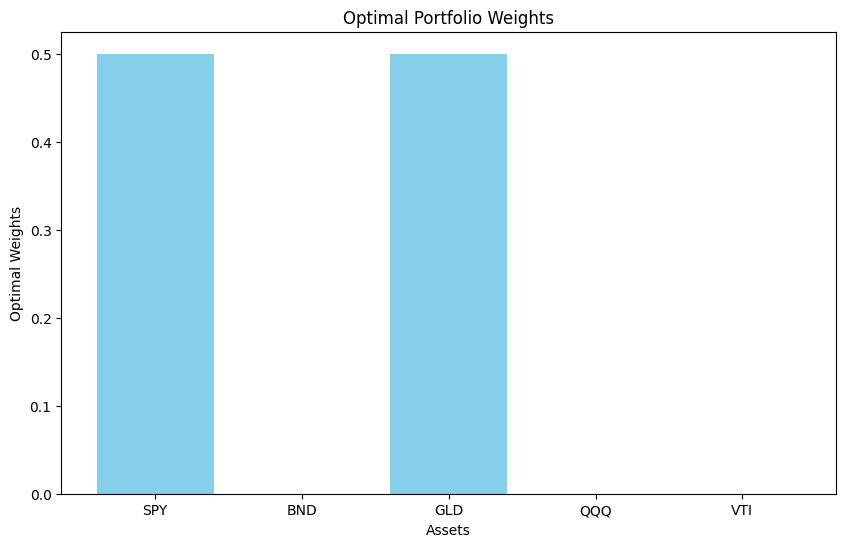

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(tickers, optimal_weights, color='skyblue')

plt.xlabel('Assets')
plt.ylabel('Optimal Weights')
plt.title('Optimal Portfolio Weights')

plt.show()